In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gona26/tinystories-slm/prep_data.py
/kaggle/input/datasets/gona26/tinystories-slm/plot.py
/kaggle/input/datasets/gona26/tinystories-slm/data_pipeline.py
/kaggle/input/datasets/gona26/tinystories-slm/learn_pipeline.py
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00002.tok.npy
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00000.tok.npy
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00003.doc.npy
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00005.doc.npy
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00001.tok.npy
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00001.doc.npy
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00002.doc.npy
/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data/shards/val/shard_00004.doc.npy
/kaggle/

In [2]:
import glob, json, numpy as np
BASE = "/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data"

# --- vocab / sequence length ---
V_bpe = len(json.load(open(f"{BASE}/bpe/vocab.json")))
V = V_bpe + 2                       # + PAD + EOS
T = 128                             # cfg.T (sequence length / context window)
print(f"vocab: BPE {V_bpe}  ->  V = {V} (with PAD+EOS)")
print(f"sequence length T = {T}")

# --- shards + tokens per split ---
def shard_stats(split):
    files = sorted(glob.glob(f"{BASE}/shards/{split}/shard_*.tok.npy"))
    sizes = [int(np.load(f, mmap_mode='r').shape[0]) for f in files]
    return files, sizes

for split in ["train", "val"]:
    files, sizes = shard_stats(split)
    print(f"\n{split}: {len(files)} shards | {sum(sizes):,} tokens")
    print(f"  tokens/shard: min {min(sizes):,}  max {max(sizes):,}")

# --- derived quantities (train) ---
_, sizes = shard_stats("train")
train_tokens = sum(sizes)
blocks = train_tokens // T
print(f"\ntrain tokens : {train_tokens:,}")
print(f"blocks (tokens // T) : {blocks:,}")
print(f"\nmicro-batches per epoch (blocks // micro_B):")
for mb in [1, 8, 16, 32, 64]:
    print(f"  micro_B={mb:2d} -> {blocks // mb:,} micro-batches   ({mb*T} tokens each)")

# --- how much a run covers ---
world = 2
print(f"\nrun coverage (world_size={world}):")
for mb, steps in [(16, 2000), (32, 5000), (32, 20000)]:
    toks = steps * world * mb * T
    print(f"  micro_B={mb} STEPS={steps:>5}: {toks:,} tokens = {toks/train_tokens:.2f} epochs")

vocab: BPE 4000  ->  V = 4002 (with PAD+EOS)
sequence length T = 128

train: 41 shards | 40,932,484 tokens
  tokens/shard: min 932,484  max 1,000,000

val: 6 shards | 5,617,526 tokens
  tokens/shard: min 617,526  max 1,000,000

train tokens : 40,932,484
blocks (tokens // T) : 319,785

micro-batches per epoch (blocks // micro_B):
  micro_B= 1 -> 319,785 micro-batches   (128 tokens each)
  micro_B= 8 -> 39,973 micro-batches   (1024 tokens each)
  micro_B=16 -> 19,986 micro-batches   (2048 tokens each)
  micro_B=32 -> 9,993 micro-batches   (4096 tokens each)
  micro_B=64 -> 4,996 micro-batches   (8192 tokens each)

run coverage (world_size=2):
  micro_B=16 STEPS= 2000: 8,192,000 tokens = 0.20 epochs
  micro_B=32 STEPS= 5000: 40,960,000 tokens = 1.00 epochs
  micro_B=32 STEPS=20000: 163,840,000 tokens = 4.00 epochs


In [3]:
import os, shutil
os.chdir("/kaggle/working")
DATA = "/kaggle/input/datasets/gona26/tinystories-slm/tinystories_data"
if not os.path.exists("data/bpe"):
    os.makedirs("data", exist_ok=True)
    shutil.copytree(f"{DATA}/bpe", "data/bpe")     # so Config() loads BPE (no retrain)
print("data/bpe:", os.listdir("data/bpe"))

data/bpe: ['vocab.json', 'merges.txt']


In [4]:
%%writefile ddp_launch.py

# read env vars torchrun injects
import os
# csv metrics logging + step timing
import csv
import time
# add the Kaggle dataset folder to the import path
import sys
# for torch.cuda.set_device
import torch
# collectives: init/barrier/etc.
import torch.distributed as dist

# dataset root holds the loose .py files; add it to the import path
SRC = "/kaggle/input/datasets/gona26/tinystories-slm"
# shards + bpe live under this subfolder
DATA = f"{SRC}/tinystories_data"
sys.path.insert(0, SRC)
# model/vocab sizes + the data stream factory
from data_pipeline import Config, get_streams
# the model + mask/loss helpers
from learn_pipeline import GPT, make_masks, loss_fn, lr_at


def setup():
    # GPU index for THIS process (str -> int)
    local_rank = int(os.environ["LOCAL_RANK"])
    # pin this process to that one GPU (must happen before init)
    torch.cuda.set_device(local_rank)
    # join the group; device_id tells NCCL our GPU (mutes the "guessing" warning)
    dist.init_process_group(
        backend="nccl",
        device_id=torch.device(f"cuda:{local_rank}"),
    )
    # (global id, total procs, gpu index)
    return dist.get_rank(), dist.get_world_size(), local_rank


def print0(rank, *args):
    # only the first process prints
    if rank == 0:
        # forward args like the real print()
        print(*args)


def param_checksum(model):
    # crude weight fingerprint; abs-sum so opposite-sign drift can't cancel out
    return sum(p.detach().abs().sum().item() for p in model.parameters())


def measure_holdings(model, opt):
    # actual bytes from live tensors (element_size() -> dtype-aware, no assumptions)
    mb = lambda ts: sum(t.numel() * t.element_size() for t in ts) / 1e6
    params_mb = mb(list(model.parameters()))
    grads_mb = mb([p.grad for p in model.parameters() if p.grad is not None])
    # optimizer state = Adam's m, v (and step) tensors, straight from opt.state
    optim_mb = mb([t for st in opt.state.values() for t in st.values() if torch.is_tensor(t)])
    return params_mb, grads_mb, optim_mb


def main():
    # every process runs this; only the numbers differ
    rank, world_size, local_rank = setup()
    # plain print -> see BOTH ranks
    print(f"rank {rank}/{world_size} on cuda:{local_rank} \n")

    # ---- 1.2: rank-aware data ----
    cfg = Config()
    micro_B = 32                                  # real data now -> big micro-batch
    # SAME seed on every rank + rank/world -> disjoint block partition (no overlap)
    train_stream, _ = get_streams(cfg, shard_dir=f"{DATA}/shards",
                                  micro_B=micro_B, seed=1234,
                                  rank=rank, world_size=world_size)
    # pull the first batch this rank would train on
    x, d = next(train_stream)
    # hash it; the two ranks MUST print different hashes
    print(f"rank {rank} first-batch hash: {hash(x.tobytes())}")

    # ---- 2.1 + 2.3: manual DDP + correct cross-rank logging ----
    device = torch.device(f"cuda:{local_rank}")
    # step budget + schedule + how often to log/eval
    STEPS, WARMUP, base_lr, LOG_EVERY = 1500, 200, 3e-4, 50
    # SAME seed on every rank -> identical initial weights (fair start)
    torch.manual_seed(0)
    model = GPT(cfg).to(device)
    # guarantee identical start: everyone copies rank 0's weights
    for p in model.parameters():
        dist.broadcast(p.data, src=0)
    opt = torch.optim.AdamW(model.parameters(), lr=base_lr)

    # rank 0 writes metrics.csv (writable working dir) for plot.py
    if rank == 0:
        logf = open("/kaggle/working/metrics.csv", "w", newline="")
        writer = csv.writer(logf)
        writer.writerow(["step", "loss", "tok_per_s", "lr", "mem_mb"])

    tok_per_step = cfg.T * micro_B * world_size   # tokens the whole job processes per step
    for s in range(1, STEPS + 1):
        t0 = time.time()
        # warmup + cosine decay schedule
        cur_lr = base_lr * lr_at(s, WARMUP, STEPS)
        for g in opt.param_groups:
            g['lr'] = cur_lr
        x, d = next(train_stream)
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        attn, loss_mask = make_masks(tokens, doc_id)
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        # DDP sync: average each gradient across ranks BEFORE stepping
        for p in model.parameters():
            if p.grad is not None:
                dist.all_reduce(p.grad)       # SUM grads over ranks
                p.grad /= world_size          # -> mean
        opt.step()                            # same averaged update on every rank
        dt = time.time() - t0

        if s % LOG_EVERY == 0:
            # 2.3: TRUE global loss = sum(loss*tokens)/sum(tokens) across ranks
            # (averaging each rank's average is wrong when token counts differ)
            stats = torch.tensor([loss.item() * n, float(n)], device=device)
            dist.all_reduce(stats)            # ALL ranks must call this collective
            avg_loss = (stats[0] / stats[1]).item()
            if rank == 0:
                mem = torch.cuda.max_memory_allocated() / 1e6
                tps = tok_per_step / max(dt, 1e-9)
                writer.writerow([s, f"{avg_loss:.4f}", f"{tps:.0f}",
                                 f"{cur_lr:.2e}", f"{mem:.0f}"])
                logf.flush()
                print(f"step {s:4d} | loss {avg_loss:.4f} | {tps:.0f} tok/s | "
                      f"mem {mem:.0f}MB", flush=True)

    if rank == 0:
        logf.close()

    # measure ACTUAL per-GPU holdings from the live objects (grads + optim now exist)
    if rank == 0:
        params_mb, grads_mb, optim_mb = measure_holdings(model, opt)
        print(f"per-GPU holdings: params {params_mb:.0f}MB grads {grads_mb:.0f}MB "
              f"optim {optim_mb:.0f}MB total {params_mb+grads_mb+optim_mb:.0f}MB", flush=True)
        with open("/kaggle/working/holdings.csv", "w", newline="") as hf:
            w = csv.writer(hf)
            w.writerow(["component", "mb"])
            w.writerow(["params", f"{params_mb:.2f}"])
            w.writerow(["grads", f"{grads_mb:.2f}"])
            w.writerow(["optimizer", f"{optim_mb:.2f}"])

    # wall: no rank passes until all reach it
    dist.barrier()
    # rank 0 only -> printed once
    print0(rank, "all ranks synced")
    # release nccl comms; pairs with init
    dist.destroy_process_group()


# entry point torchrun runs in each process
if __name__ == "__main__":
    # start the program
    main()

# ---- after training, plot the metrics (run in a NORMAL notebook cell) ----
#   import sys; sys.path.append(BASE)      # BASE holds plot.py once you upload it
#   from plot import plot_metrics
#   plot_metrics("/kaggle/working/metrics.csv", "/kaggle/working/plots")
#   from IPython.display import Image; Image("/kaggle/working/plots/training.png")

Writing ddp_launch.py


In [5]:
!torchrun --nproc_per_node=2 ddp_launch.py

W0928 18:28:44.228000 49 torch/distributed/run.py:852] 
W0928 18:28:44.228000 49 torch/distributed/run.py:852] *****************************************
W0928 18:28:44.228000 49 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0928 18:28:44.228000 49 torch/distributed/run.py:852] *****************************************
rank 0/2 on cuda:0 
rank 1/2 on cuda:1 


rank 1 first-batch hash: 1551702892833459143
rank 0 first-batch hash: 7886328618458282207
step   50 | loss 7.4646 | 26507 tok/s | mem 1220MB
step  100 | loss 5.7643 | 19566 tok/s | mem 1220MB
step  150 | loss 4.8860 | 30634 tok/s | mem 1220MB
step  200 | loss 4.3188 | 21367 tok/s | mem 1220MB
step  250 | loss 4.3525 | 35376 tok/s | mem 1220MB
step  300 | loss 3.9461 | 35511 tok/s | mem 1220MB
step  350 | loss 3.9105 | 35097 tok/s | mem 122

In [6]:
%%writefile zero3_launch.py

# read env vars torchrun injects
import os
# csv metrics logging + step timing
import csv
import time
# add the Kaggle dataset folder to the import path
import sys
# for torch.cuda.set_device
import torch
# collectives: init/all_reduce/broadcast
import torch.distributed as dist
# ZeRO-3 engine: shards params + grads + optimizer, gathers layer-by-layer
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp import ShardingStrategy
from torch.distributed.fsdp.wrap import ModuleWrapPolicy

# dataset root holds the loose .py files; add it to the import path
SRC = "/kaggle/input/datasets/gona26/tinystories-slm"
# shards + bpe live under this subfolder
DATA = f"{SRC}/tinystories_data"
sys.path.insert(0, SRC)
# model/vocab sizes + the data stream factory
from data_pipeline import Config, get_streams
# model + a Block (the unit we shard) + RMSNorm (needs custom init) + helpers
from learn_pipeline import GPT, Block, RMSNorm, make_masks, loss_fn, lr_at


def setup():
    # CPU: read this process's GPU index that torchrun injected (str -> int)
    local_rank = int(os.environ["LOCAL_RANK"])
    # GPU: pin this process to that one GPU (must happen before init)
    torch.cuda.set_device(local_rank)
    # GPU<->GPU: join the process group; device_id tells NCCL our GPU
    dist.init_process_group(
        backend="nccl",
        device_id=torch.device(f"cuda:{local_rank}"),
    )
    # CPU: return identity read back from the group
    return dist.get_rank(), dist.get_world_size(), local_rank


def print0(rank, *args):
    if rank == 0:
        print(*args, flush=True)


def model_info(model, cfg):
    P = sum(p.numel() for p in model.parameters())    # numel works on meta tensors too
    emb = 2 * cfg.V * cfg.D
    return (f"model: {P/1e6:.2f}M params | L={cfg.L} D={cfg.D} H={cfg.H} "
            f"T={cfg.T} V={cfg.V} | embed+head ~{emb/1e6:.1f}M ({100*emb/P:.0f}%)")


def measure_holdings(model, opt):
    # actual bytes from live tensors; under FSDP these are the LOCAL shards (1/N)
    mb = lambda ts: sum(t.numel() * t.element_size() for t in ts) / 1e6
    params_mb = mb(list(model.parameters()))
    grads_mb = mb([p.grad for p in model.parameters() if p.grad is not None])
    optim_mb = mb([t for st in opt.state.values() for t in st.values() if torch.is_tensor(t)])
    return params_mb, grads_mb, optim_mb


def param_init_fn(module):
    # FSDP calls this per module while sharding, to bring META tensors to life:
    # allocate real (uninitialized) tensors on THIS process's GPU...
    module.to_empty(device=torch.cuda.current_device(), recurse=False)
    # ...then set proper initial values (meta tensors carried none)
    with torch.no_grad():
        if isinstance(module, RMSNorm):
            module.g.fill_(1.0)                 # RMSNorm gain starts at 1
        elif hasattr(module, "reset_parameters"):
            module.reset_parameters()           # Linear/Embedding default init


def main():
    rank, world_size, local_rank = setup()
    device = torch.device(f"cuda:{local_rank}")
    print(f"rank {rank}/{world_size} on cuda:{local_rank}", flush=True)

    # ---- data: disjoint blocks per rank (shared seed) ----
    # CPU: Config builds tokenizer; the stream reads shards into numpy (numpy = CPU RAM)
    cfg = Config()
    micro_B = 32
    # CPU: sets up the numpy batch iterator (no GPU touched here)
    train_stream, _ = get_streams(cfg, shard_dir=f"{DATA}/shards",
                                  micro_B=micro_B, seed=1234,
                                  rank=rank, world_size=world_size)

    STEPS, WARMUP, base_lr, LOG_EVERY = 1500, 100, 3e-4, 50
    torch.manual_seed(0)
    # META init: build the model with SHAPES ONLY -> ZERO bytes allocated, so the full
    # model never lands on any single GPU (this is what avoids OOM for huge models).
    with torch.device("meta"):
        model = GPT(cfg)
    print0(rank, model_info(model, cfg))

    # ---- ZeRO-3: shard params across ranks; FSDP materializes only each rank's 1/N ----
    # GPU: FULL_SHARD = ZeRO-3 (params + grads + optimizer sharded). param_init_fn builds
    # + inits each shard on the GPU, so the whole model is never assembled in one place.
    # (SHARD_GRAD_OP would be ZeRO-2; NO_SHARD would be plain DDP.)
    model = FSDP(
        model,
        # each Block is gathered/freed on its own -> peak memory = ~one Block
        auto_wrap_policy=ModuleWrapPolicy({Block}),
        sharding_strategy=ShardingStrategy.FULL_SHARD,
        device_id=local_rank,
        param_init_fn=param_init_fn,
    )
    # CPU setup over GPU-resident sharded params: MUST be built AFTER FSDP so it sees
    # the sharded (flat) params; its m/v state is allocated on GPU at first step, 1/N size
    opt = torch.optim.AdamW(model.parameters(), lr=base_lr)
    print0(rank, model)

    if rank == 0:
        logf = open("/kaggle/working/metrics_zero3.csv", "w", newline="")
        writer = csv.writer(logf)
        writer.writerow(["step", "loss", "tok_per_s", "lr", "mem_mb"])

    tok_per_step = cfg.T * micro_B * world_size
    for s in range(1, STEPS + 1):
        t0 = time.time()
        # CPU: schedule math (plain floats), then push the LR onto the optimizer
        cur_lr = base_lr * lr_at(s, WARMUP, STEPS)
        for g in opt.param_groups:
            g['lr'] = cur_lr
        # CPU: pull one numpy micro-batch off the stream
        x, d = next(train_stream)
        # CPU->GPU: numpy -> GPU tensors (from_numpy is CPU, .to(device) copies over)
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        # GPU: build the attention/loss masks on the data's device
        attn, loss_mask = make_masks(tokens, doc_id)
        # GPU (+ GPU<->GPU comms): FSDP forward all_gathers each Block's full params
        # just-in-time, runs it, then FREES them -> peak memory ~ one Block
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        # GPU: drop stale grads
        opt.zero_grad(set_to_none=True)
        # GPU (+ comms): backward gathers params again, computes grads, then
        # reduce_scatters them -> each rank KEEPS ONLY ITS SHARD of the gradients
        loss.backward()
        # GPU: each rank updates ONLY its param shard (no manual all_reduce/broadcast)
        opt.step()
        # CPU: wall-clock for this step (GPU work already synced by the collectives)
        dt = time.time() - t0

        if s % LOG_EVERY == 0:
            # GPU<->GPU: sum (loss*tokens) and tokens across ranks -> true global mean
            stats = torch.tensor([loss.item() * n, float(n)], device=device)
            dist.all_reduce(stats)
            # GPU->CPU: .item() pulls the scalar back to host for printing/logging
            avg_loss = (stats[0] / stats[1]).item()
            if rank == 0:
                # GPU->CPU: read peak memory counter
                mem = torch.cuda.max_memory_allocated() / 1e6
                tps = tok_per_step / max(dt, 1e-9)
                # CPU: write the row to disk
                writer.writerow([s, f"{avg_loss:.4f}", f"{tps:.0f}",
                                 f"{cur_lr:.2e}", f"{mem:.0f}"])
                logf.flush()
                print(f"step {s:4d} | loss {avg_loss:.4f} | {tps:.0f} tok/s | "
                      f"mem {mem:.0f}MB", flush=True)

    if rank == 0:
        logf.close()

    # per-rank holdings: params + grads + optim should ALL be ~1/world_size now
    params_mb, grads_mb, optim_mb = measure_holdings(model, opt)
    print(f"rank {rank} holdings: params {params_mb:.0f}MB grads {grads_mb:.0f}MB "
          f"optim {optim_mb:.0f}MB total {params_mb+grads_mb+optim_mb:.0f}MB", flush=True)
    if rank == 0:
        with open("/kaggle/working/holdings_zero3.csv", "w", newline="") as hf:
            w = csv.writer(hf)
            w.writerow(["component", "mb"])
            w.writerow(["params", f"{params_mb:.2f}"])
            w.writerow(["grads", f"{grads_mb:.2f}"])
            w.writerow(["optimizer", f"{optim_mb:.2f}"])

    dist.barrier()
    print0(rank, "done")
    dist.destroy_process_group()


if __name__ == "__main__":
    main()

# ---- after training, plot / compare (normal notebook cell) ----
#   from plot import plot_holdings, compare
#   plot_holdings("/kaggle/working/holdings_zero3.csv", "/kaggle/working/plots")
#   compare(["/kaggle/working/metrics.csv",
#            "/kaggle/working/metrics_zero1.csv",
#            "/kaggle/working/metrics_zero3.csv"], ["DDP", "ZeRO-1", "ZeRO-3"])


Writing zero3_launch.py


In [7]:
!torchrun --nproc_per_node=2 zero3_launch.py

W0928 18:35:32.993000 82 torch/distributed/run.py:852] 
W0928 18:35:32.993000 82 torch/distributed/run.py:852] *****************************************
W0928 18:35:32.993000 82 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0928 18:35:32.993000 82 torch/distributed/run.py:852] *****************************************
rank 0/2 on cuda:0
rank 1/2 on cuda:1
model: 8.38M params | L=6 D=256 H=8 T=128 V=4002 | embed+head ~2.0M (24%)
FullyShardedDataParallel(
  (_fsdp_wrapped_module): GPT(
    (tok_emb): Embedding(4002, 256)
    (pos_emb): Embedding(128, 256)
    (blocks): ModuleList(
      (0-5): 6 x FullyShardedDataParallel(
        (_fsdp_wrapped_module): Block(
          (attn): Attention(
            (q): Linear(in_features=256, out_features=256, bias=False)
            (k): Linear(in_features=2

In [8]:
%%writefile zero2_launch.py

# read env vars torchrun injects
import os
# csv metrics logging + step timing
import csv
import time
# add the Kaggle dataset folder to the import path
import sys
# for torch.cuda.set_device
import torch
# collectives: init/reduce/broadcast
import torch.distributed as dist

# dataset root holds the loose .py files; add it to the import path
SRC = "/kaggle/input/datasets/gona26/tinystories-slm"
# shards + bpe live under this subfolder
DATA = f"{SRC}/tinystories_data"
sys.path.insert(0, SRC)
# model/vocab sizes + the data stream factory
from data_pipeline import Config, get_streams
# the model + mask/loss helpers
from learn_pipeline import GPT, make_masks, loss_fn, lr_at


def setup():
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    dist.init_process_group(backend="nccl",
                            device_id=torch.device(f"cuda:{local_rank}"))
    return dist.get_rank(), dist.get_world_size(), local_rank


def print0(rank, *args):
    if rank == 0:
        print(*args, flush=True)


def model_info(model, cfg):
    P = sum(p.numel() for p in model.parameters())
    emb = 2 * cfg.V * cfg.D
    return (f"model: {P/1e6:.2f}M params | L={cfg.L} D={cfg.D} H={cfg.H} "
            f"T={cfg.T} V={cfg.V} | embed+head ~{emb/1e6:.1f}M ({100*emb/P:.0f}%)")


def measure_holdings(model, opt):
    # ACTUAL bytes from live tensors (element_size() -> real dtype, no formula)
    mb = lambda ts: sum(t.numel() * t.element_size() for t in ts) / 1e6
    params_mb = mb(list(model.parameters()))                          # FULL (replicated)
    grads_mb = mb([p.grad for p in model.parameters() if p.grad is not None])  # only owned -> 1/N
    optim_mb = mb([t for st in opt.state.values() for t in st.values() if torch.is_tensor(t)])
    return params_mb, grads_mb, optim_mb


def main():
    rank, world_size, local_rank = setup()
    device = torch.device(f"cuda:{local_rank}")
    print(f"rank {rank}/{world_size} on cuda:{local_rank}", flush=True)

    cfg = Config()
    micro_B = 32
    train_stream, _ = get_streams(cfg, shard_dir=f"{DATA}/shards",
                                  micro_B=micro_B, seed=1234,
                                  rank=rank, world_size=world_size)

    STEPS, WARMUP, base_lr, LOG_EVERY = 1500, 100, 3e-4, 50
    torch.manual_seed(0)
    model = GPT(cfg).to(device)
    print0(rank, model_info(model, cfg))
    for p in model.parameters():
        dist.broadcast(p.data, src=0)                    # identical start on every rank

    # ---- ZeRO-2: params FULL, but grads + optimizer SHARDED ----
    params = list(model.parameters())
    owner = [i % world_size for i in range(len(params))]  # which rank owns each param
    my_params = [p for i, p in enumerate(params) if owner[i] == rank]
    opt = torch.optim.AdamW(my_params, lr=base_lr)        # optimizer over my shard only

    if rank == 0:
        logf = open("/kaggle/working/metrics_zero2.csv", "w", newline="")
        writer = csv.writer(logf)
        writer.writerow(["step", "loss", "tok_per_s", "lr", "mem_mb"])
    tok_per_step = cfg.T * micro_B * world_size

    for s in range(1, STEPS + 1):
        t0 = time.time()
        cur_lr = base_lr * lr_at(s, WARMUP, STEPS)
        for g in opt.param_groups:
            g['lr'] = cur_lr
        x, d = next(train_stream)
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        attn, loss_mask = make_masks(tokens, doc_id)
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        for p in params:
            p.grad = None
        loss.backward()
        # ZeRO-2 grad sharding: REDUCE each grad to its owner, then non-owners FREE it
        # (ZeRO-1 used all_reduce -> every rank kept the full grad; here grad memory shrinks)
        for i, p in enumerate(params):
            if p.grad is not None:
                dist.reduce(p.grad, dst=owner[i])         # sum grad onto the owner rank
                if owner[i] == rank:
                    p.grad /= world_size                  # owner keeps the averaged grad
                else:
                    p.grad = None                         # non-owner drops it -> sharded grads
        opt.step()                                        # each owner updates its params
        for i, p in enumerate(params):
            dist.broadcast(p.data, src=owner[i])          # re-sync full params
        dt = time.time() - t0

        if s % LOG_EVERY == 0:
            stats = torch.tensor([loss.item() * n, float(n)], device=device)
            dist.all_reduce(stats)
            avg_loss = (stats[0] / stats[1]).item()
            if rank == 0:
                mem = torch.cuda.max_memory_allocated() / 1e6
                tps = tok_per_step / max(dt, 1e-9)
                writer.writerow([s, f"{avg_loss:.4f}", f"{tps:.0f}",
                                 f"{cur_lr:.2e}", f"{mem:.0f}"])
                logf.flush()
                print(f"step {s:4d} | loss {avg_loss:.4f} | {tps:.0f} tok/s | "
                      f"mem {mem:.0f}MB", flush=True)

    if rank == 0:
        logf.close()
    # holdings: params FULL, grads + optim ~ 1/world_size
    params_mb, grads_mb, optim_mb = measure_holdings(model, opt)
    print(f"rank {rank} holdings: params {params_mb:.0f}MB grads {grads_mb:.0f}MB "
          f"optim {optim_mb:.0f}MB total {params_mb+grads_mb+optim_mb:.0f}MB", flush=True)
    if rank == 0:
        with open("/kaggle/working/holdings_zero2.csv", "w", newline="") as hf:
            w = csv.writer(hf)
            w.writerow(["component", "mb"])
            w.writerow(["params", f"{params_mb:.2f}"])
            w.writerow(["grads", f"{grads_mb:.2f}"])
            w.writerow(["optimizer", f"{optim_mb:.2f}"])

    dist.barrier()
    print0(rank, "done")
    dist.destroy_process_group()


if __name__ == "__main__":
    main()


Writing zero2_launch.py


In [9]:
!torchrun --nproc_per_node=2 zero2_launch.py

W0928 18:42:40.590000 115 torch/distributed/run.py:852] 
W0928 18:42:40.590000 115 torch/distributed/run.py:852] *****************************************
W0928 18:42:40.590000 115 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0928 18:42:40.590000 115 torch/distributed/run.py:852] *****************************************
rank 0/2 on cuda:0
rank 1/2 on cuda:1
model: 8.38M params | L=6 D=256 H=8 T=128 V=4002 | embed+head ~2.0M (24%)
step   50 | loss 6.6352 | 38235 tok/s | mem 1169MB
step  100 | loss 5.1779 | 33480 tok/s | mem 1169MB
step  150 | loss 4.3523 | 38741 tok/s | mem 1169MB
step  200 | loss 4.2876 | 33191 tok/s | mem 1169MB
step  250 | loss 3.9268 | 34152 tok/s | mem 1169MB
step  300 | loss 3.8718 | 34070 tok/s | mem 1169MB
step  350 | loss 3.6714 | 30193 tok/s | mem 1169MB
step  400 | 

In [10]:
%%writefile zero1_launch.py

# read env vars torchrun injects
import os
# csv metrics logging + step timing
import csv
import time
# add the Kaggle dataset folder to the import path
import sys
# for torch.cuda.set_device
import torch
# collectives: init/all_reduce/broadcast
import torch.distributed as dist

# dataset root holds the loose .py files; add it to the import path
SRC = "/kaggle/input/datasets/gona26/tinystories-slm"
# shards + bpe live under this subfolder
DATA = f"{SRC}/tinystories_data"
sys.path.insert(0, SRC)
# model/vocab sizes + the data stream factory
from data_pipeline import Config, get_streams
# the model + mask/loss helpers
from learn_pipeline import GPT, make_masks, loss_fn, lr_at


def setup():
    # GPU index for THIS process (str -> int)
    local_rank = int(os.environ["LOCAL_RANK"])
    # pin this process to that one GPU (must happen before init)
    torch.cuda.set_device(local_rank)
    # join the group; device_id tells NCCL our GPU
    dist.init_process_group(
        backend="nccl",
        device_id=torch.device(f"cuda:{local_rank}"),
    )
    return dist.get_rank(), dist.get_world_size(), local_rank


def print0(rank, *args):
    if rank == 0:
        print(*args, flush=True)


def model_info(model, cfg):
    P = sum(p.numel() for p in model.parameters())
    emb = 2 * cfg.V * cfg.D
    return (f"model: {P/1e6:.2f}M params | L={cfg.L} D={cfg.D} H={cfg.H} "
            f"T={cfg.T} V={cfg.V} | embed+head ~{emb/1e6:.1f}M ({100*emb/P:.0f}%)")


def measure_holdings(model, opt):
    # actual bytes from live tensors (element_size() -> dtype-aware)
    mb = lambda ts: sum(t.numel() * t.element_size() for t in ts) / 1e6
    params_mb = mb(list(model.parameters()))
    grads_mb = mb([p.grad for p in model.parameters() if p.grad is not None])
    # optimizer state now covers only THIS rank's shard -> smaller
    optim_mb = mb([t for st in opt.state.values() for t in st.values() if torch.is_tensor(t)])
    return params_mb, grads_mb, optim_mb


def main():
    rank, world_size, local_rank = setup()
    device = torch.device(f"cuda:{local_rank}")
    print(f"rank {rank}/{world_size} on cuda:{local_rank}", flush=True)

    # ---- data: disjoint blocks per rank (shared seed) ----
    # CPU: Config + the stream read shards into numpy (numpy is always CPU RAM)
    cfg = Config()
    micro_B = 32
    train_stream, _ = get_streams(cfg, shard_dir=f"{DATA}/shards",
                                  micro_B=micro_B, seed=1234,
                                  rank=rank, world_size=world_size)

    STEPS, WARMUP, base_lr, LOG_EVERY = 1500, 100, 3e-4, 50
    torch.manual_seed(0)
    # GPT(cfg) builds + inits all weights on CPU; .to(device) copies them to THIS GPU
    model = GPT(cfg).to(device)
    print0(rank, model_info(model, cfg))
    # GPU->GPU: copy rank 0's weights to every rank so all replicas start identical
    for p in model.parameters():
        dist.broadcast(p.data, src=0)

    # ---- ZeRO-1: partition params across ranks; optimizer holds only MY shard ----
    # CPU: a Python list of references (the weight tensors themselves stay on GPU)
    params = list(model.parameters())
    # CPU: plain Python ints, one owner rank per param (no tensors involved)
    owner = [i % world_size for i in range(len(params))]
    # CPU: filter to my tensors (still just references; data stays on GPU)
    my_params = [p for i, p in enumerate(params) if owner[i] == rank]
    # CPU setup: builds the optimizer object; its m/v state is allocated on GPU
    # lazily at the FIRST opt.step(), sized to my_params only (the memory saving)
    opt = torch.optim.AdamW(my_params, lr=base_lr)

    if rank == 0:
        logf = open("/kaggle/working/metrics_zero1.csv", "w", newline="")
        writer = csv.writer(logf)
        writer.writerow(["step", "loss", "tok_per_s", "lr", "mem_mb"])

    tok_per_step = cfg.T * micro_B * world_size
    for s in range(1, STEPS + 1):
        t0 = time.time()
        cur_lr = base_lr * lr_at(s, WARMUP, STEPS)
        for g in opt.param_groups:
            g['lr'] = cur_lr
        x, d = next(train_stream)
        # CPU->GPU: batch is numpy (CPU); move it onto this rank's GPU
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        attn, loss_mask = make_masks(tokens, doc_id)
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        # zero ALL grads (full model still does a full backward)
        for p in params:
            p.grad = None
        loss.backward()
        # gradients are still FULLY averaged across ranks (same as DDP)
        for p in params:
            if p.grad is not None:
                dist.all_reduce(p.grad)
                p.grad /= world_size
        # each rank updates ONLY its owned params (its optimizer shard)
        opt.step()
        # re-sync: each param's OWNER broadcasts its freshly-updated weights to all
        # (init broadcast used src=0; here src=owner[i] -> the rank that just stepped it)
        for i, p in enumerate(params):
            dist.broadcast(p.data, src=owner[i])
        dt = time.time() - t0

        if s % LOG_EVERY == 0:
            # true global loss across ranks (sum loss*tokens / sum tokens)
            stats = torch.tensor([loss.item() * n, float(n)], device=device)
            dist.all_reduce(stats)
            avg_loss = (stats[0] / stats[1]).item()
            if rank == 0:
                mem = torch.cuda.max_memory_allocated() / 1e6
                tps = tok_per_step / max(dt, 1e-9)
                writer.writerow([s, f"{avg_loss:.4f}", f"{tps:.0f}",
                                 f"{cur_lr:.2e}", f"{mem:.0f}"])
                logf.flush()
                print(f"step {s:4d} | loss {avg_loss:.4f} | {tps:.0f} tok/s | "
                      f"mem {mem:.0f}MB", flush=True)

    if rank == 0:
        logf.close()

    # per-rank holdings: optimizer should be ~1/world_size of the DDP value
    params_mb, grads_mb, optim_mb = measure_holdings(model, opt)
    print(f"rank {rank} holdings: params {params_mb:.0f}MB grads {grads_mb:.0f}MB "
          f"optim {optim_mb:.0f}MB total {params_mb+grads_mb+optim_mb:.0f}MB", flush=True)
    if rank == 0:
        with open("/kaggle/working/holdings_zero1.csv", "w", newline="") as hf:
            w = csv.writer(hf)
            w.writerow(["component", "mb"])
            w.writerow(["params", f"{params_mb:.2f}"])
            w.writerow(["grads", f"{grads_mb:.2f}"])
            w.writerow(["optimizer", f"{optim_mb:.2f}"])

    dist.barrier()
    print0(rank, "done")
    dist.destroy_process_group()


if __name__ == "__main__":
    main()

# ---- after training, plot / compare (normal notebook cell) ----
#   from plot import plot_metrics, plot_holdings, compare
#   plot_holdings("/kaggle/working/holdings_zero1.csv", "/kaggle/working/plots")
#   compare(["/kaggle/working/metrics.csv", "/kaggle/working/metrics_zero1.csv"],
#           ["DDP", "ZeRO-1"])


Writing zero1_launch.py


In [11]:
!torchrun --nproc_per_node=2 zero1_launch.py

W0928 18:49:37.353000 148 torch/distributed/run.py:852] 
W0928 18:49:37.353000 148 torch/distributed/run.py:852] *****************************************
W0928 18:49:37.353000 148 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0928 18:49:37.353000 148 torch/distributed/run.py:852] *****************************************
rank 1/2 on cuda:1rank 0/2 on cuda:0

model: 8.38M params | L=6 D=256 H=8 T=128 V=4002 | embed+head ~2.0M (24%)
step   50 | loss 6.6352 | 36876 tok/s | mem 1186MB
step  100 | loss 5.1779 | 37829 tok/s | mem 1186MB
step  150 | loss 4.3523 | 36917 tok/s | mem 1186MB
step  200 | loss 4.2876 | 38306 tok/s | mem 1186MB
step  250 | loss 3.9268 | 35346 tok/s | mem 1186MB
step  300 | loss 3.8718 | 31552 tok/s | mem 1186MB
step  350 | loss 3.6714 | 39323 tok/s | mem 1186MB
step  400 | 

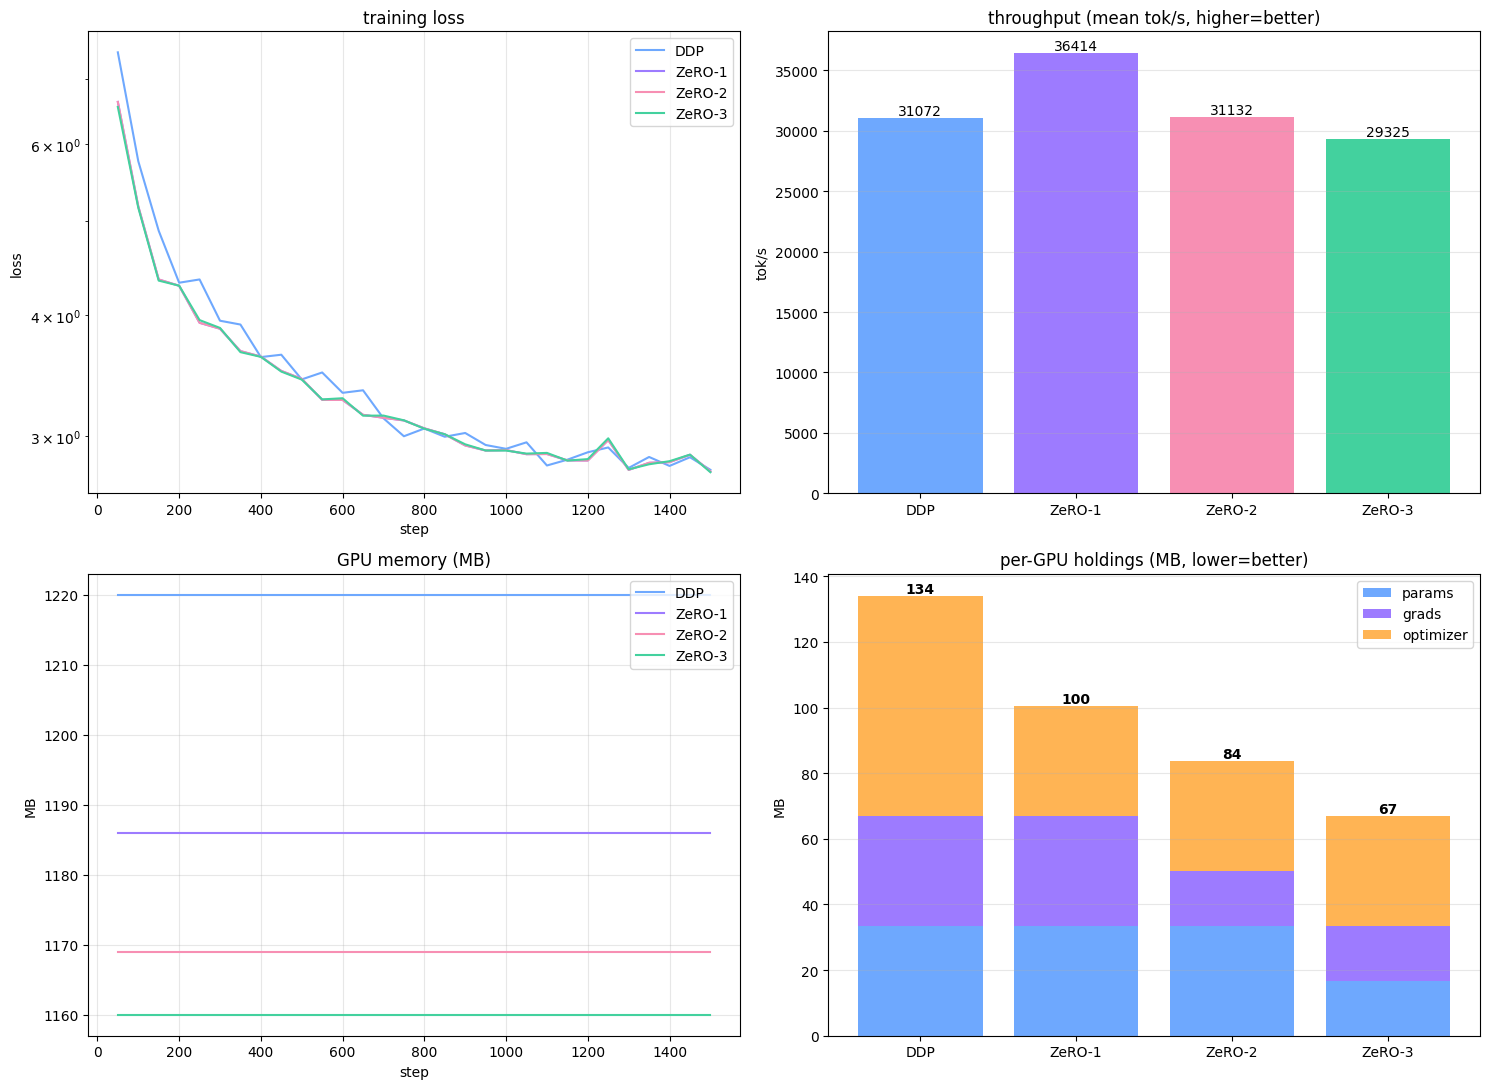

approach     tok/s   peak MB   hold MB
DDP          31072      1220       134
ZeRO-1       36414      1186       100
ZeRO-2       31132      1169        84
ZeRO-3       29325      1160        67


In [12]:
%matplotlib inline
import csv, numpy as np, matplotlib.pyplot as plt

def load(path):
    cols = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            for k, v in row.items():
                try: v = float(v)
                except (ValueError, TypeError): pass
                cols.setdefault(k, []).append(v)
    return cols

def load_holdings(path):
    d = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            d[row["component"]] = float(row["mb"])
    return d

# name -> (metrics.csv, holdings.csv)
runs = {
    "DDP":    ("/kaggle/working/metrics.csv",       "/kaggle/working/holdings.csv"),
    "ZeRO-1": ("/kaggle/working/metrics_zero1.csv", "/kaggle/working/holdings_zero1.csv"),
    "ZeRO-2": ("/kaggle/working/metrics_zero2.csv", "/kaggle/working/holdings_zero2.csv"),
    "ZeRO-3": ("/kaggle/working/metrics_zero3.csv", "/kaggle/working/holdings_zero3.csv"),
}
colors = {"DDP":"#6ea8fe", "ZeRO-1":"#9d7bff", "ZeRO-2":"#f78fb3", "ZeRO-3":"#43d19e"}

metrics, hold = {}, {}
for name, (mp, hp) in runs.items():
    try: metrics[name] = load(mp)
    except FileNotFoundError: print("missing", mp)
    try: hold[name] = load_holdings(hp)
    except FileNotFoundError: print("missing", hp)

fig, ax = plt.subplots(2, 2, figsize=(15, 11))

# 1) loss overlay (correctness: should track together)
for n, m in metrics.items():
    ax[0,0].plot(m["step"], m["loss"], label=n, color=colors[n])
ax[0,0].set(title="training loss", xlabel="step", ylabel="loss")
ax[0,0].set_yscale("log"); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

# 2) throughput (mean tok/s)
names = list(metrics); tps = [np.mean(metrics[n]["tok_per_s"]) for n in names]
b = ax[0,1].bar(names, tps, color=[colors[n] for n in names]); ax[0,1].bar_label(b, fmt="%.0f")
ax[0,1].set(title="throughput (mean tok/s, higher=better)", ylabel="tok/s"); ax[0,1].grid(alpha=.3, axis="y")

# 3) GPU memory over steps
for n, m in metrics.items():
    ax[1,0].plot(m["step"], m["mem_mb"], label=n, color=colors[n])
ax[1,0].set(title="GPU memory (MB)", xlabel="step", ylabel="MB"); ax[1,0].legend(); ax[1,0].grid(alpha=.3)

# 4) holdings stacked (params / grads / optimizer)
comps = ["params","grads","optimizer"]; ccol = ["#6ea8fe","#9d7bff","#ffb454"]
hn = list(hold); hd = np.array([[hold[n].get(c,0) for c in comps] for n in hn])
bottom = np.zeros(len(hn))
for i, c in enumerate(comps):
    ax[1,1].bar(hn, hd[:,i], bottom=bottom, label=c, color=ccol[i]); bottom += hd[:,i]
for x, tot in enumerate(hd.sum(axis=1)):
    ax[1,1].text(x, tot, f"{tot:.0f}", ha="center", va="bottom", fontweight="bold")
ax[1,1].set(title="per-GPU holdings (MB, lower=better)", ylabel="MB"); ax[1,1].legend(); ax[1,1].grid(alpha=.3, axis="y")

plt.tight_layout(); plt.show()

# summary table
print(f"{'approach':<8}{'tok/s':>10}{'peak MB':>10}{'hold MB':>10}")
for n in metrics:
    peak = max(metrics[n]["mem_mb"]) if "mem_mb" in metrics[n] else 0
    hmb  = sum(hold[n].values()) if n in hold else 0
    print(f"{n:<8}{np.mean(metrics[n]['tok_per_s']):>10.0f}{peak:>10.0f}{hmb:>10.0f}")

In [13]:
%%writefile zero3_manual.py
#
# Manual ZeRO-3 -- what FSDP does, written out by hand (TEACHING reference).
# Simplifications vs real FSDP: shards only the transformer Blocks (embeddings/head
# stay replicated + DDP-synced), no comm/compute overlap, no prefetch. The point is
# to SEE the mechanism: shard params -> gather full weights per Block just-in-time ->
# run -> free; reduce_scatter grads in backward.

import os
import sys
import csv
import time

import torch
import torch.nn as nn
import torch.distributed as dist
from torch.func import functional_call          # run a module with externally-supplied params

BASE = "/kaggle/input/datasets/gona26/tinystories-slm"
DATA = f"{BASE}/tinystories_data"
sys.path.insert(0, BASE)
from data_pipeline import Config, get_streams
from learn_pipeline import GPT, Block, RMSNorm, make_masks, loss_fn, lr_at


def setup():
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    dist.init_process_group(backend="nccl",
                            device_id=torch.device(f"cuda:{local_rank}"))
    return dist.get_rank(), dist.get_world_size(), local_rank


def measure_holdings(model, opt):
    # actual bytes from live tensors: shards + replicated root params (skip emptied)
    mb = lambda ts: sum(t.numel() * t.element_size() for t in ts) / 1e6
    params_mb = mb([p for p in model.parameters() if p.numel() > 0])
    grads_mb = mb([p.grad for p in model.parameters() if p.grad is not None])
    optim_mb = mb([t for st in opt.state.values() for t in st.values() if torch.is_tensor(t)])
    return params_mb, grads_mb, optim_mb


# ---- the heart of ZeRO-3: gather a sharded param in forward, scatter its grad in backward ----
class AllGather(torch.autograd.Function):
    @staticmethod
    def forward(ctx, shard, world_size, numel, shape):
        ctx.world_size = world_size
        ctx.shard_numel = shard.numel()
        # FORWARD = all_gather: pull every rank's slice -> rebuild the FULL param
        buffers = [torch.empty_like(shard) for _ in range(world_size)]
        dist.all_gather(buffers, shard.contiguous())
        full = torch.cat(buffers)[:numel].view(shape)     # drop padding, restore shape
        return full

    @staticmethod
    def backward(ctx, grad_full):
        ws = ctx.world_size
        # BACKWARD = reduce_scatter: sum grads across ranks, each rank KEEPS ONLY ITS SLICE
        grad_flat = grad_full.reshape(-1)
        pad = ctx.shard_numel * ws - grad_flat.numel()
        if pad:
            grad_flat = torch.cat([grad_flat, grad_flat.new_zeros(pad)])
        chunks = list(grad_flat.chunk(ws))
        out = torch.empty_like(chunks[0])
        dist.reduce_scatter(out, chunks)                  # out = sum over ranks of chunks[rank]
        out /= ws                                         # average (data-parallel mean)
        return out, None, None, None                      # grads only for `shard`


# ---- wraps ONE module: stores only this rank's shard of each weight, gathers on forward ----
class ShardedModule(nn.Module):
    def __init__(self, module, world_size, rank, device):
        super().__init__()
        self.mod = module
        self.ws, self.rank = world_size, rank
        # META -> real: materialize + init THIS module only (one Block at a time -> low peak,
        # the full model is never assembled on one GPU)
        module.to_empty(device=device, recurse=True)
        for sub in module.modules():
            with torch.no_grad():
                if isinstance(sub, RMSNorm):
                    sub.g.fill_(1.0)
                elif hasattr(sub, "reset_parameters"):
                    sub.reset_parameters()
        # make the full weights identical across ranks so shards are consistent slices
        for p in module.parameters():
            dist.broadcast(p.data, src=0)
        # keep ONLY my 1/world_size chunk of each weight, then FREE the full weight
        self.meta = {}                                    # orig name -> (key, numel, shape)
        self.shards = nn.ParameterDict()
        for name, p in list(module.named_parameters()):
            flat = p.detach().reshape(-1)
            pad = (-flat.numel()) % world_size            # pad so it splits evenly
            if pad:
                flat = torch.cat([flat, flat.new_zeros(pad)])
            key = name.replace(".", "__")
            self.shards[key] = nn.Parameter(flat.chunk(world_size)[rank].clone())
            self.meta[name] = (key, p.numel(), tuple(p.shape))
        with torch.no_grad():
            for p in module.parameters():
                p.set_(torch.empty(0, device=device))     # drop the full weight

    def forward(self, *args, **kwargs):
        # gather every weight just-in-time -> a dict of FULL params
        full = {name: AllGather.apply(self.shards[key], self.ws, numel, shape)
                for name, (key, numel, shape) in self.meta.items()}
        # run the original module using those gathered params (nothing stored on self.mod)
        out = functional_call(self.mod, full, args, kwargs)
        return out                                        # `full` frees when it goes out of scope


def main():
    rank, world_size, local_rank = setup()
    device = torch.device(f"cuda:{local_rank}")

    cfg = Config()
    micro_B = 32
    train_stream, _ = get_streams(cfg, shard_dir=f"{DATA}/shards",
                                  micro_B=micro_B, seed=1234,
                                  rank=rank, world_size=world_size)

    STEPS, WARMUP, base_lr, LOG_EVERY = 1500, 100, 3e-4, 50
    torch.manual_seed(0)
    # META init: shapes only, ZERO bytes -> the full model is never built on one GPU
    with torch.device("meta"):
        model = GPT(cfg)

    # shard each Block: each ShardedModule materializes+inits+shards itself, one at a
    # time -> peak memory ~ one Block, never the whole model
    model.blocks = nn.ModuleList(
        [ShardedModule(blk, world_size, rank, device) for blk in model.blocks]
    )
    # materialize the still-replicated root modules (embeddings / final norm / head)
    for m in (model.tok_emb, model.pos_emb, model.ns, model.head):
        m.to_empty(device=device, recurse=True)
        for sub in m.modules():
            with torch.no_grad():
                if isinstance(sub, RMSNorm):
                    sub.g.fill_(1.0)
                elif hasattr(sub, "reset_parameters"):
                    sub.reset_parameters()
    # root params = replicated (not inside a ShardedModule's .shards); sync across ranks
    root_params = [p for n, p in model.named_parameters()
                   if ".shards." not in n and p.numel() > 0]
    for p in root_params:
        dist.broadcast(p.data, src=0)
    # optimize the shards + the root params (skip the emptied originals)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.numel() > 0], lr=base_lr)

    if rank == 0:
        logf = open("/kaggle/working/metrics_zero3_manual.csv", "w", newline="")
        writer = csv.writer(logf)
        writer.writerow(["step", "loss", "tok_per_s", "lr", "mem_mb"])
    tok_per_step = cfg.T * micro_B * world_size

    for s in range(1, STEPS + 1):
        t0 = time.time()
        cur_lr = base_lr * lr_at(s, WARMUP, STEPS)
        for g in opt.param_groups:
            g["lr"] = cur_lr
        x, d = next(train_stream)
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        attn, loss_mask = make_masks(tokens, doc_id)
        # forward: each ShardedModule all_gathers its Block, runs it, frees it
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        opt.zero_grad(set_to_none=True)
        # backward: Block grads are reduce_scattered automatically by AllGather.backward
        loss.backward()
        # root (replicated) params still need a manual DDP-style all_reduce
        for p in root_params:
            if p.grad is not None:
                dist.all_reduce(p.grad)
                p.grad /= world_size
        opt.step()
        dt = time.time() - t0

        if s % LOG_EVERY == 0:
            stats = torch.tensor([loss.item() * n, float(n)], device=device)
            dist.all_reduce(stats)
            avg_loss = (stats[0] / stats[1]).item()
            if rank == 0:
                mem = torch.cuda.max_memory_allocated() / 1e6
                tps = tok_per_step / max(dt, 1e-9)
                writer.writerow([s, f"{avg_loss:.4f}", f"{tps:.0f}",
                                 f"{cur_lr:.2e}", f"{mem:.0f}"])
                logf.flush()
                print(f"step {s:4d} | loss {avg_loss:.4f} | {tps:.0f} tok/s | "
                      f"mem {mem:.0f}MB", flush=True)

    if rank == 0:
        logf.close()
    # per-rank holdings (sharded Blocks + replicated root): compare vs DDP / ZeRO-1 / FSDP
    params_mb, grads_mb, optim_mb = measure_holdings(model, opt)
    print(f"rank {rank} holdings: params {params_mb:.0f}MB grads {grads_mb:.0f}MB "
          f"optim {optim_mb:.0f}MB total {params_mb+grads_mb+optim_mb:.0f}MB", flush=True)
    if rank == 0:
        with open("/kaggle/working/holdings_zero3_manual.csv", "w", newline="") as hf:
            w = csv.writer(hf)
            w.writerow(["component", "mb"])
            w.writerow(["params", f"{params_mb:.2f}"])
            w.writerow(["grads", f"{grads_mb:.2f}"])
            w.writerow(["optimizer", f"{optim_mb:.2f}"])

    dist.barrier()
    if rank == 0:
        print("done", flush=True)
    dist.destroy_process_group()


if __name__ == "__main__":
    main()


Writing zero3_manual.py


In [14]:
!torchrun --nproc_per_node=2 zero3_manual.py

W0928 18:55:27.030000 184 torch/distributed/run.py:852] 
W0928 18:55:27.030000 184 torch/distributed/run.py:852] *****************************************
W0928 18:55:27.030000 184 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0928 18:55:27.030000 184 torch/distributed/run.py:852] *****************************************
step   50 | loss 6.5564 | 34561 tok/s | mem 1194MB
step  100 | loss 5.1619 | 32013 tok/s | mem 1194MB
step  150 | loss 4.3405 | 31804 tok/s | mem 1194MB
step  200 | loss 4.2887 | 34220 tok/s | mem 1194MB
step  250 | loss 3.9520 | 32420 tok/s | mem 1194MB
step  300 | loss 3.8792 | 31420 tok/s | mem 1194MB
step  350 | loss 3.6624 | 26989 tok/s | mem 1194MB
step  400 | loss 3.6216 | 34285 tok/s | mem 1194MB
step  450 | loss 3.4970 | 34596 tok/s | mem 1194MB
step  500 | loss 3.431

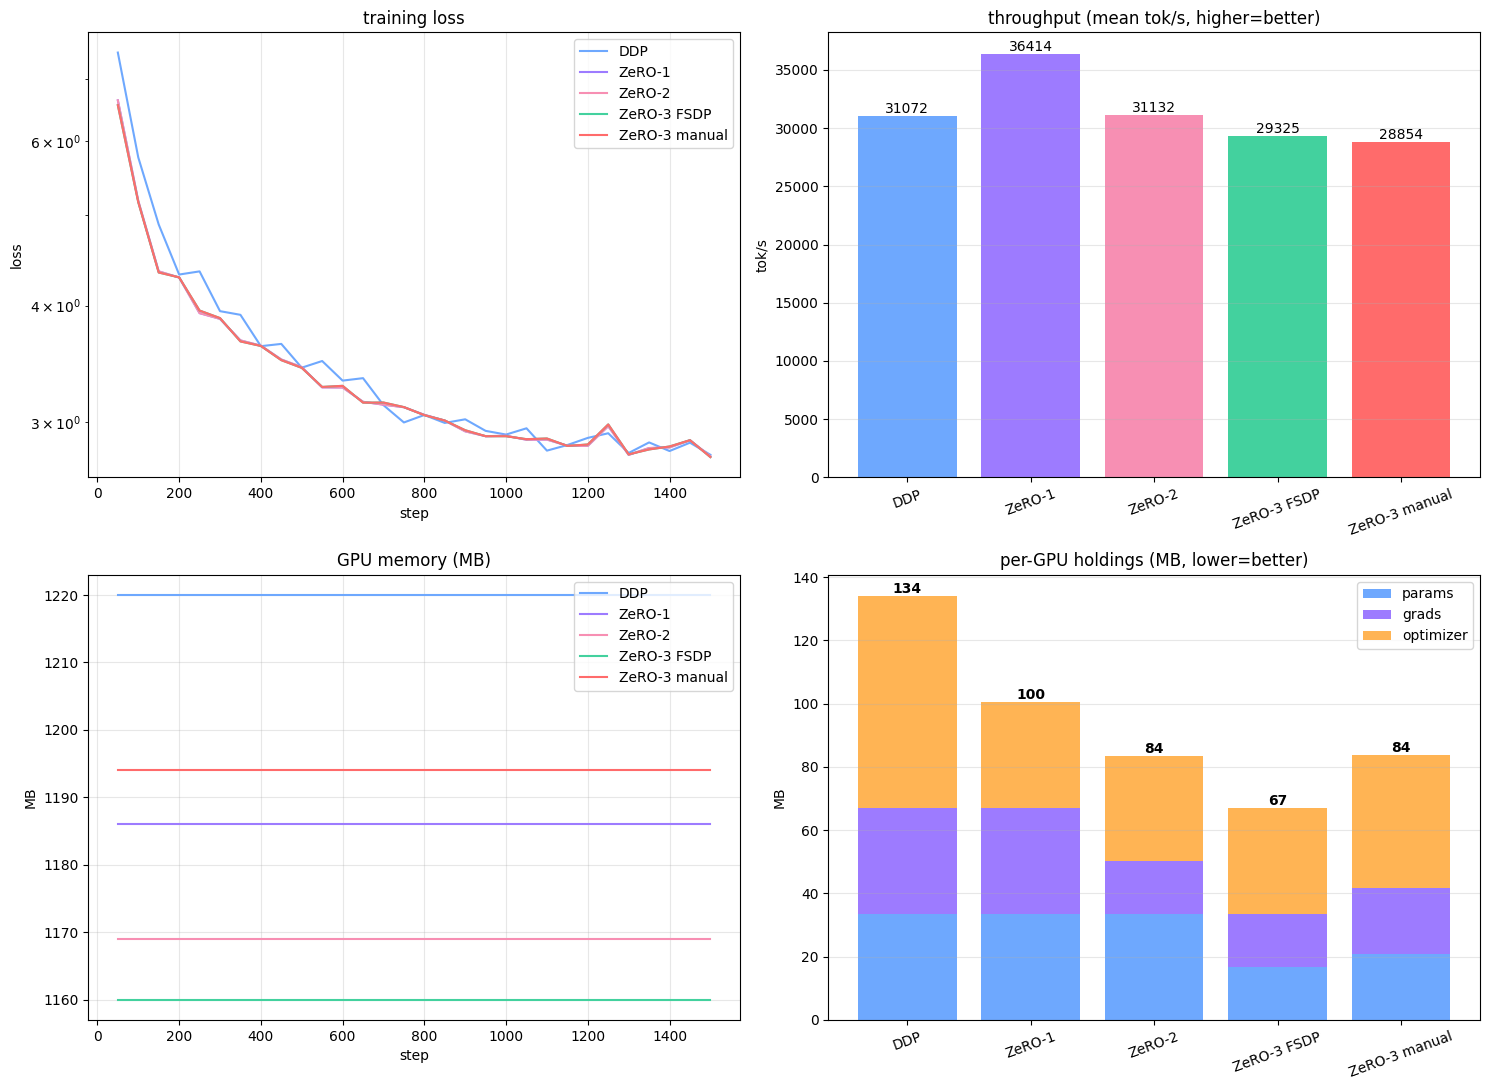

approach          tok/s   peak MB   hold MB
DDP               31072      1220       134
ZeRO-1            36414      1186       100
ZeRO-2            31132      1169        84
ZeRO-3 FSDP       29325      1160        67
ZeRO-3 manual     28854      1194        84


In [15]:
%matplotlib inline
import csv, numpy as np, matplotlib.pyplot as plt

def load(path):
    cols = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            for k, v in row.items():
                try: v = float(v)
                except (ValueError, TypeError): pass
                cols.setdefault(k, []).append(v)
    return cols

def load_holdings(path):
    d = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            d[row["component"]] = float(row["mb"])
    return d

# name -> (metrics.csv, holdings.csv)
runs = {
    "DDP":         ("/kaggle/working/metrics.csv",              "/kaggle/working/holdings.csv"),
    "ZeRO-1":      ("/kaggle/working/metrics_zero1.csv",        "/kaggle/working/holdings_zero1.csv"),
    "ZeRO-2":      ("/kaggle/working/metrics_zero2.csv",        "/kaggle/working/holdings_zero2.csv"),
    "ZeRO-3 FSDP": ("/kaggle/working/metrics_zero3.csv",        "/kaggle/working/holdings_zero3.csv"),
    "ZeRO-3 manual": ("/kaggle/working/metrics_zero3_manual.csv", "/kaggle/working/holdings_zero3_manual.csv"),
}
colors = {"DDP":"#6ea8fe", "ZeRO-1":"#9d7bff", "ZeRO-2":"#f78fb3",
          "ZeRO-3 FSDP":"#43d19e", "ZeRO-3 manual":"#ff6b6b"}

metrics, hold = {}, {}
for name, (mp, hp) in runs.items():
    try: metrics[name] = load(mp)
    except FileNotFoundError: print("missing", mp)
    try: hold[name] = load_holdings(hp)
    except FileNotFoundError: print("missing", hp)

fig, ax = plt.subplots(2, 2, figsize=(15, 11))

# 1) loss overlay (correctness)
for n, m in metrics.items():
    ax[0,0].plot(m["step"], m["loss"], label=n, color=colors[n])
ax[0,0].set(title="training loss", xlabel="step", ylabel="loss")
ax[0,0].set_yscale("log"); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

# 2) throughput (mean tok/s)
names = list(metrics); tps = [np.mean(metrics[n]["tok_per_s"]) for n in names]
b = ax[0,1].bar(names, tps, color=[colors[n] for n in names]); ax[0,1].bar_label(b, fmt="%.0f")
ax[0,1].set(title="throughput (mean tok/s, higher=better)", ylabel="tok/s")
ax[0,1].tick_params(axis="x", rotation=20); ax[0,1].grid(alpha=.3, axis="y")

# 3) GPU memory over steps
for n, m in metrics.items():
    ax[1,0].plot(m["step"], m["mem_mb"], label=n, color=colors[n])
ax[1,0].set(title="GPU memory (MB)", xlabel="step", ylabel="MB"); ax[1,0].legend(); ax[1,0].grid(alpha=.3)

# 4) holdings stacked (params / grads / optimizer)
comps = ["params","grads","optimizer"]; ccol = ["#6ea8fe","#9d7bff","#ffb454"]
hn = list(hold); hd = np.array([[hold[n].get(c,0) for c in comps] for n in hn])
bottom = np.zeros(len(hn))
for i, c in enumerate(comps):
    ax[1,1].bar(hn, hd[:,i], bottom=bottom, label=c, color=ccol[i]); bottom += hd[:,i]
for x, tot in enumerate(hd.sum(axis=1)):
    ax[1,1].text(x, tot, f"{tot:.0f}", ha="center", va="bottom", fontweight="bold")
ax[1,1].set(title="per-GPU holdings (MB, lower=better)", ylabel="MB")
ax[1,1].tick_params(axis="x", rotation=20); ax[1,1].legend(); ax[1,1].grid(alpha=.3, axis="y")

plt.tight_layout(); plt.show()

# summary table
print(f"{'approach':<13}{'tok/s':>10}{'peak MB':>10}{'hold MB':>10}")
for n in metrics:
    peak = max(metrics[n]["mem_mb"]) if "mem_mb" in metrics[n] else 0
    hmb  = sum(hold[n].values()) if n in hold else 0
    print(f"{n:<13}{np.mean(metrics[n]['tok_per_s']):>10.0f}{peak:>10.0f}{hmb:>10.0f}")